In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



EXPENSE TRACKER
1. Add Expense
2. View Expenses
3. Calculate Total Expenses
4. Visualize Expenses
5. Exit


Enter your choice:  1
Enter the date (YYYY-MM-DD):  2000-12-299
Enter the category (e.g., Food, Travel, Shopping):  food
Enter the amount:  3000
Enter a description (optional):  no


Expense added successfully!

EXPENSE TRACKER
1. Add Expense
2. View Expenses
3. Calculate Total Expenses
4. Visualize Expenses
5. Exit


Enter your choice:  2



Expense History:
--------------------------------------------------
Date: 2000-03-29
Category: food
Amount: 8000.00
Description: nothing else
--------------------------------------------------
Date: 2000-03-29
Category: Travel
Amount: 3000.00
Description: nothing fucker
--------------------------------------------------
Date: 2013-12-23
Category: sex
Amount: 4000.00
Description: nothing
--------------------------------------------------
Date: 2000-12-3
Category: food
Amount: 400.00
Description: no
--------------------------------------------------
Date: 2000-12-299
Category: food
Amount: 3000.00
Description: no
--------------------------------------------------

EXPENSE TRACKER
1. Add Expense
2. View Expenses
3. Calculate Total Expenses
4. Visualize Expenses
5. Exit


Enter your choice:  3



Total Expenses: 18400.00

EXPENSE TRACKER
1. Add Expense
2. View Expenses
3. Calculate Total Expenses
4. Visualize Expenses
5. Exit


Enter your choice:  4


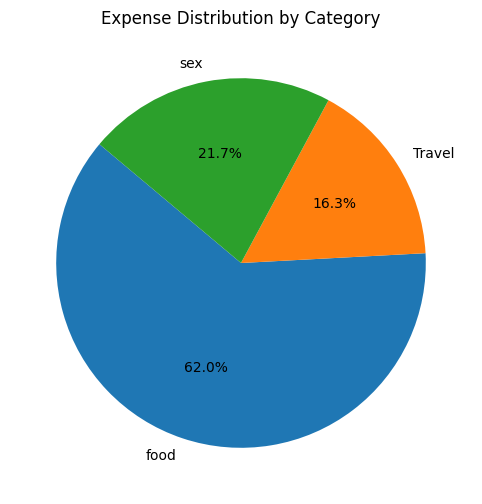


EXPENSE TRACKER
1. Add Expense
2. View Expenses
3. Calculate Total Expenses
4. Visualize Expenses
5. Exit


Enter your choice:  5


Exiting Expense Tracker. Goodbye!


In [2]:
#I have not added  sql in this code 
import json #jason is a syntax used for storing and exchanging data we can convert python into jason using json.dumps()
import matplotlib.pyplot as plt

# File to save expenses
FILE_NAME = "expenses.json"

# Function to load expenses from a file
def load_expenses():
    try:
        with open(FILE_NAME, "r") as file:
            return json.load(file)
    except FileNotFoundError:
        return  

# Function to save expenses to a file
def save_expenses(expenses):
    with open(FILE_NAME, "w") as file:
        json.dump(expenses, file, indent=4)

# Function to add a new expense
def add_expense(expenses):
    date = input("Enter the date (YYYY-MM-DD): ")
    category = input("Enter the category (e.g., Food, Travel, Shopping): ")
    amount = float(input("Enter the amount: "))
    description = input("Enter a description (optional): ")

    expense = {
        "date": date,
        "category": category,
        "amount": amount,
        "description": description
    }
    expenses.append(expense)
    save_expenses(expenses)
    print("Expense added successfully!")

# Function to view all expenses
def view_expenses(expenses):
    if not expenses:
        print("No expenses recorded.")
        return

    print("\nExpense History:")
    print("-" * 50)
    for expense in expenses:
        print(f"Date: {expense['date']}")
        print(f"Category: {expense['category']}")
        print(f"Amount: {expense['amount']:.2f}")
        print(f"Description: {expense['description']}")
        print("-" * 50)

# Function to calculate total expenses
def calculate_total(expenses):
    total = sum(expense["amount"] for expense in expenses)
    print(f"\nTotal Expenses: {total:.2f}")

# Function to visualize expenses
def visualize_expenses(expenses):
    if not expenses:
        print("No expenses to visualize.")
        return

    # Calculate total amount for each category
    category_totals = {}
    for expense in expenses:
        category = expense["category"]
        amount = expense["amount"]
        category_totals[category] = category_totals.get(category, 0) + amount

    # Prepare data for the pie chart
    categories = list(category_totals.keys())
    amounts = list(category_totals.values())

    # Plot pie chart
    plt.figure(figsize=(8, 6))
    plt.pie(amounts, labels=categories, autopct='%1.1f%%', startangle=140)
    plt.title("Expense Distribution by Category")
    plt.show()

# Main function
def main():
    expenses = load_expenses()
    while True:
        print("\nEXPENSE TRACKER")
        print("1. Add Expense")
        print("2. View Expenses")
        print("3. Calculate Total Expenses")
        print("4. Visualize Expenses")
        print("5. Exit")
        
        choice = input("Enter your choice: ")
        if choice == "1":
            add_expense(expenses)
        elif choice == "2":
            view_expenses(expenses)
        elif choice == "3":
            calculate_total(expenses)
        elif choice == "4":
            visualize_expenses(expenses)
        elif choice == "5":
            print("Exiting Expense Tracker. Goodbye!")
            break
        else:
            print("Invalid choice. Please try again.")

if __name__ == "__main__":
    main()


In [ ]:

# SAME PROJECT WITH SQL DATABASE ADD ON IN IT
import sqlite3
import matplotlib.pyplot as plt

# Database setup
DB_NAME = "expenses.db"

# Initialize the database
def init_db():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS expenses (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            date TEXT,
            category TEXT,
            amount REAL,
            description TEXT
        )
    """)
    conn.commit()
    conn.close()

# Add a new expense
def add_expense():
    date = input("Enter the date (YYYY-MM-DD): ")
    category = input("Enter the category (e.g., Food, Travel, Shopping): ")
    amount = float(input("Enter the amount: "))
    description = input("Enter a description (optional): ")

    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        INSERT INTO expenses (date, category, amount, description)
        VALUES (?, ?, ?, ?)
    """, (date, category, amount, description))
    conn.commit()
    conn.close()
    print("Expense added successfully!")

# View all expenses
def view_expenses():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM expenses")
    rows = cursor.fetchall()
    conn.close()

    if not rows:
        print("No expenses recorded.")
        return

    print("\nExpense History:")
    print("-" * 50)
    for row in rows:
        print(f"ID: {row[0]}")
        print(f"Date: {row[1]}")
        print(f"Category: {row[2]}")
        print(f"Amount: {row[3]:.2f}")
        print(f"Description: {row[4]}")
        print("-" * 50)

# Calculate total expenses
def calculate_total():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT SUM(amount) FROM expenses")
    total = cursor.fetchone()[0]
    conn.close()

    total = total if total else 0
    print(f"\nTotal Expenses: {total:.2f}")

# Visualize expenses
def visualize_expenses():
    conn = sqlite3.connect(DB_NAME)
    cursor = conn.cursor()
    cursor.execute("SELECT category, SUM(amount) FROM expenses GROUP BY category")
    rows = cursor.fetchall()
    conn.close()

    if not rows:
        print("No expenses to visualize.")
        return

    categories = [row[0] for row in rows]
    amounts = [row[1] for row in rows]

    # Plot pie chart
    plt.figure(figsize=(8, 6))
    plt.pie(amounts, labels=categories, autopct='%1.1f%%', startangle=140)
    plt.title("Expense Distribution by Category")
    plt.show()

# Main function
def main():
    init_db()
    while True:
        print("\nExpense Tracker")
        print("1. Add Expense")
        print("2. View Expenses")
        print("3. Calculate Total Expenses")
        print("4. Visualize Expenses")
        print("5. Exit")
        
        choice = input("Enter your choice: ")
        if choice == "1":
            add_expense()
        elif choice == "2":
            view_expenses()
        elif choice == "3":
            calculate_total()
        elif choice == "4":
            visualize_expenses()
        elif choice == "5":
            print("Exiting Expense Tracker. Goodbye!")
            break
        else:
            print("Invalid choice. Please try again.")

if __name__ == "__main__":
    main()
4



In [ ]:
8
